### 1. Сформулювати завдання в галузі обчислювальної техніки, для вирішення якої було б обґрунтовано застосування гібридної нейронечіткої мережі.

**Завдання:**  
Розробка системи оцінювання надійності паролів користувачів для інформаційних систем, яка враховує як формальні характеристики пароля (довжина, наявність цифр, спеціальних символів, регістрів, послідовностей тощо), так і нечіткі експертні правила (наприклад, "пароль занадто схожий на слово зі словника" або "пароль містить підозрілу послідовність символів").  

Завдання характеризується наявністю як чітких числових ознак, так і нечітких, експертних критеріїв, що складно формалізуються. Гібридна нейронечітка мережа (наприклад, ANFIS) дозволяє поєднати можливості нечіткої логіки для роботи з експертними правилами та нейронних мереж для автоматичного навчання на основі даних, забезпечуючи гнучкість і високу якість класифікації складності паролів.

In [ ]:
import pandas as pd

df_weak = pd.read_csv("pswds/weak.csv", nrows=1000)
df_average = pd.read_csv("pswds/average.csv", nrows=1000)
df_strong = pd.read_csv("pswds/strong.csv", nrows=1000)
df = pd.concat([df_weak, df_average, df_strong], ignore_index=True)
df.head()

,Password,Strength_Level
0,Activate9999,1
1,bbbbadjurer4,1
2,asdfadinole5,1
3,acetoinAsdf,1
4,qweabsurdly3,1


### 2. Формування вибірки для навчання гібридної нейронної мережі.

Для навчання гібридної нейронної мережі (ANFIS) сформуємо вибірку з ознак, що характеризують паролі, та цільової змінної — рівня складності пароля.

**Ознаки (фічі):**
- length — довжина пароля
- has_upper — наявність великих літер
- has_lower — наявність малих літер
- has_digit — наявність цифр
- has_special — наявність спеціальних символів
- has_seq — наявність підозрілих послідовностей
- maxHackTimeH — оцінка часу злому (години)

**Цільова змінна:**
- Strength_Level — рівень складності пароля (1 — слабкий, 2 — середній, 3 — сильний)

**Формування вибірки:**

```python
features = ['length', 'has_upper', 'has_lower', 'has_digit', 'has_special', 'has_seq', 'maxHackTimeH']
X = df[features]
y = df['Strength_Level']
```

Тепер `X` — матриця ознак, а `y` — цільова змінна для навчання моделі.

In [ ]:
def addInfo(pswd):
    length = len(pswd)
    has_upper = any(c.isupper() for c in pswd)
    has_lower = any(c.islower() for c in pswd)
    has_digit = any(c.isdigit() for c in pswd)
    has_special = any(not c.isalnum() for c in pswd)

    with open("seq.txt", "r") as f:
        sequences = [line.strip() for line in f if line.strip()]

    has_seq = any(seq in pswd for seq in sequences)

    base = (
        (26 if has_lower else 0)
        + (26 if has_upper else 0)
        + (10 if has_digit else 0)
        + (10 if has_special else 0)
    )
    pswd_hour = 1_000_000_000 * 360
    maxHackTimeH = (base**length) / pswd_hour

    return [
        length,
        has_upper,
        has_lower,
        has_digit,
        has_special,
        has_seq,
        int(round(maxHackTimeH)),
    ]


df[
    [
        "length",
        "has_upper",
        "has_lower",
        "has_digit",
        "has_special",
        "has_seq",
        "maxHackTimeH",
    ]
] = df["Password"].apply(lambda x: pd.Series(addInfo(x)))
df.head()

,Password,Strength_Level,length,has_upper,has_lower,has_digit,has_special,has_seq,maxHackTimeH
0,Activate9999,1,12,True,True,True,False,True,8961852118
1,bbbbadjurer4,1,12,False,True,True,False,False,13162170
2,asdfadinole5,1,12,False,True,True,False,True,13162170
3,acetoinAsdf,1,11,True,True,False,False,False,20880182
4,qweabsurdly3,1,12,False,True,True,False,False,13162170


### 3. Структура гібридної нейронної мережі.

**Візуалізація структури гібридної нейронечіткої мережі (ANFIS)**

На діаграмі нижче зображено архітектуру ANFIS для задачі класифікації складності паролів:

- **Вхідні ознаки:**  
	- length (довжина)
	- upper (наявність великих літер)
	- lower (наявність малих літер)
	- digit (наявність цифр)
	- special (наявність спецсимволів)
	- seq (наявність підозрілих послідовностей)
	- hack time (оцінка часу злому)

- **Фазифікація:**  
	Кожна ознака перетворюється у нечіткі множини (F1–F4).

- **Правила:**  
	Формуються експертні та навчувані правила (R1–R4), що поєднують фазифіковані ознаки.

- **Нейромережа:**  
	Нейронні вузли (N1–N3) виконують агрегацію та навчання ваг.

- **Вихід:**  
	Остаточна оцінка складності пароля (Strength).

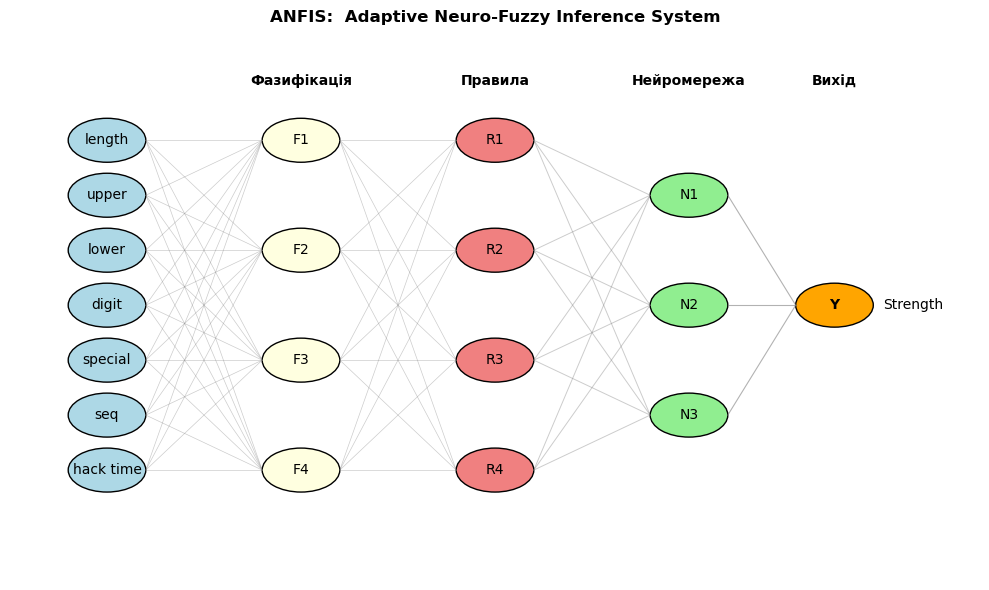

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

RADIUS = 0.4

inputs = ["length", "upper", "lower", "digit", "special", "seq", "hack time"]
y_pos = 8
for i, inp in enumerate(inputs):
    y = y_pos - i
    ax.add_patch(patches.Circle((1, y), RADIUS, color="lightblue", ec="black"))
    ax.text(1, y, inp, fontsize=10, va="center", ha="center")

ax.text(3, 9, "Фазифікація", fontsize=10, weight="bold", ha="center")
fuzz_y = [8, 6, 4, 2]
for i, y in enumerate(fuzz_y):
    ax.add_patch(patches.Circle((3, y), RADIUS, color="lightyellow", ec="black"))
    ax.text(3, y, f"F{i+1}", fontsize=10, va="center", ha="center")

ax.text(5, 9, "Правила", fontsize=10, weight="bold", ha="center")
rules_y = [8, 6, 4, 2]
for i, y in enumerate(rules_y):
    ax.add_patch(patches.Circle((5, y), RADIUS, color="lightcoral", ec="black"))
    ax.text(5, y, f"R{i+1}", fontsize=10, va="center", ha="center")

ax.text(7, 9, "Нейромережа", fontsize=10, weight="bold", ha="center")
nn_y = [7, 5, 3]
for i, y in enumerate(nn_y):
    ax.add_patch(patches.Circle((7, y), RADIUS, color="lightgreen", ec="black"))
    ax.text(7, y, f"N{i+1}", fontsize=10, va="center", ha="center")

ax.text(8.5, 9, "Вихід", fontsize=10, weight="bold", ha="center")
ax.add_patch(patches.Circle((8.5, 5), RADIUS, color="orange", ec="black"))
ax.text(8.5, 5, "Y", fontsize=10, va="center", ha="center", weight="bold")
ax.text(9, 5, "Strength", fontsize=10, va="center")

for i in range(len(inputs)):
    y1 = y_pos - i
    for y2 in fuzz_y:
        ax.plot([1 + RADIUS, 3 - RADIUS], [y1, y2], "gray", lw=0.5, alpha=0.4)

for y1 in fuzz_y:
    for y2 in rules_y:
        ax.plot([3 + RADIUS, 5 - RADIUS], [y1, y2], "gray", lw=0.5, alpha=0.4)

for y1 in rules_y:
    for y2 in nn_y:
        ax.plot([5 + RADIUS, 7 - RADIUS], [y1, y2], "gray", lw=0.7, alpha=0.4)

for y1 in nn_y:
    ax.plot([7 + RADIUS, 8.5 - RADIUS], [y1, 5], "gray", lw=0.8, alpha=0.6)

plt.title("ANFIS:  Adaptive Neuro-Fuzzy Inference System", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

### 4. Навчання гібридної нейронної мережі

Побудуємо та навчимо нейронну мережу за допомогою бібліотеки **TensorFlow**. Мережа буде апроксимувати залежність між характеристиками пароля та його складністю.

In [4]:
import os
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[
    [
        "length",
        "has_upper",
        "has_lower",
        "has_digit",
        "has_special",
        "has_seq",
        "maxHackTimeH",
    ]
].values
y = df["Strength_Level"].values - 1

# Розділення на навчальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(3, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1,
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4450 - loss: 0.9678 - val_accuracy: 0.7250 - val_loss: 0.9063
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7417 - loss: 0.7645 - val_accuracy: 0.7650 - val_loss: 0.7393
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7517 - loss: 0.6254 - val_accuracy: 0.7533 - val_loss: 0.6626
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7479 - loss: 0.5613 - val_accuracy: 0.7533 - val_loss: 0.6212
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7483 - loss: 0.5321 - val_accuracy: 0.7517 - val_loss: 0.6035
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7421 - loss: 0.5178 - val_accuracy: 0.7533 - val_loss: 0.5841
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7471 - loss: 0.5067 - val_accuracy: 0.7500 - val_loss: 0.5757
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7421 - loss: 0.4995 - val_accuracy: 0.7500 - val_loss:

**Обґрунтування параметрів навчання:**

*   **Архітектура:** Використано просту повнозв'язну мережу (MLP) з двома прихованими шарами (16 та 8 нейронів). Це дозволяє моделі вивчити нелінійні залежності без надмірної складності (overfitting) для такої кількості ознак.
*   **Функція активації:** `ReLU` у прихованих шарах забезпечує швидке навчання та запобігає затуханню градієнта. `Softmax` на виході необхідний для багатокласової класифікації (отримання ймовірностей для 3 класів).
*   **Оптимізатор:** `Adam` обрано як стандартний ефективний алгоритм, що адаптує швидкість навчання.
*   **Функція втрат:** `Sparse Categorical Crossentropy` підходить для класифікації, де мітки класів є цілими числами.
*   **Епохи:** 20 епох достатньо для стабілізації точності на такому обсязі даних.

### 5. Побудова системи нечіткого виводу

Реалізуємо просту систему нечіткого виводу, яка базується на експертних правилах. Це дозволить порівняти "чорну скриньку" нейромережі зі зрозумілою логікою нечітких правил.

In [ ]:
def fuzzy_predict_single(length, has_special, has_digit, has_seq):
    # 1. Фазифікація
    len_short = 1 if length < 8 else 0
    len_medium = 1 if 8 <= length <= 12 else 0
    len_long = 1 if length > 12 else 0

    # 2. Правила
    scores = {0: 0.0, 1: 0.0, 2: 0.0}

    # Якщо короткий або є послідовність -> Слабкий
    if len_short or has_seq:
        scores[0] += 1.0

    # Якщо середній і є цифри -> Середній
    if len_medium:
        scores[1] += 0.8
        if not has_special:
            scores[1] += 0.2

    # Якщо довгий і є спецсимволи -> Сильний
    if len_long and has_special:
        scores[2] += 1.0
    
    # Довгий, але без спецсимволів -> середній
    elif len_long:
        scores[1] += 0.8  

    # Дуже сильні вимоги
    if length > 10 and has_special and has_digit and not has_seq:
        scores[2] += 1.5

    # 3. Дефазифікація
    return max(scores, key=scores.get)


X_test_original = scaler.inverse_transform(X_test_scaled)

y_pred_fuzzy = []
for row in X_test_original:
    pred = fuzzy_predict_single(
        length=row[0],
        has_special=bool(row[4]),
        has_digit=bool(row[3]),
        has_seq=bool(row[5]),
    )
    y_pred_fuzzy.append(pred)

y_pred_fuzzy = np.array(y_pred_fuzzy)

### 6. Перевірка адекватності моделі

Порівняємо точність навченої нейронної мережі (Data-driven підхід) та експертної нечіткої системи (Rule-based підхід).

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Оцінка нейромережі
loss, acc_nn = model.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_nn_probs = model.predict(X_test_scaled)
y_pred_nn = np.argmax(y_pred_nn_probs, axis=1)

print(f"Точність Нейронної Мережі: {acc_nn*100:.2f}%")

# Оцінка нечіткої системи
acc_fuzzy = accuracy_score(y_test, y_pred_fuzzy)
print(f"Точність Нечіткої Системи: {acc_fuzzy*100:.2f}%")

print("\nЗвіт класифікації (Нейромережа):\n")
print(
    classification_report(y_test, y_pred_nn, target_names=["Weak", "Average", "Strong"])
)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Точність Нейронної Мережі: 77.33%
Точність Нечіткої Системи: 36.17%

Звіт класифікації (Нейромережа):

              precision    recall  f1-score   support

        Weak       0.84      0.93      0.88       217
     Average       0.70      0.89      0.78       197
      Strong       0.79      0.47      0.59       186

    accuracy                           0.77       600
   macro avg       0.78      0.76      0.75       600
weighted avg       0.78      0.77      0.76       600

